In [10]:
import pandas as pd
import numpy as np
from importlib import reload; import promethee2; reload(promethee2)

# =========================================================
# IMPORT YOUR PROMETHEE FUNCTIONS
# =========================================================

from promethee2 import calc_promethee2_phi, rank_using_promethee2

# =========================================================
# LOAD EXCEL FILE
# =========================================================

file_path = r"C:\Users\ACER\Desktop\Nasir\Sensitivity analysis\Decision support system\Book1.xlsx"

df = pd.read_excel(file_path, sheet_name="Sheet1")

# =========================================================
# SELECT CRITERIA
# =========================================================

criteria_columns = [
    'Embodied impact(kgCO2)',
    'Life cycle impact(kgCO2)',
    'GRIHA-2019 score'
]

# Remove whitespace-only strings
df[criteria_columns] = df[criteria_columns].replace(r'^\s*$', np.nan, regex=True)

# Convert to numeric
df[criteria_columns] = df[criteria_columns].apply(pd.to_numeric, errors='coerce')

# Check if any non-numeric values remain
print(df[criteria_columns].isna().sum())

# If appropriate, remove those rows
df = df.dropna(subset=criteria_columns)

# Convert to NumPy array
data = df[criteria_columns].to_numpy(dtype=float)

# =========================================================
# CONVERT COST → BENEFIT
# =========================================================

data[:, 0] = -data[:, 0]   # Embodied impact (kgCO2)
data[:, 1] = -data[:, 1]   # Life cycle impact (kgCO2)
# =========================================================
# CALCULATE PROMETHEE-II
# =========================================================

phi_values = calc_promethee2_phi(
    perf_matrix=data,
    criteria='usual',
    equal_weights=False
)

ranks = rank_using_promethee2(
    perf_matrix=data,
    criteria='usual',
    equal_weights=False
)

# =========================================================
# STORE RESULTS
# =========================================================

df['Phi'] = phi_values

# Convert the ordering returned by np.argsort() into actual ranks
order = np.argsort(-phi_values)      # Best (highest Phi) to worst
ranks = np.empty_like(order)
ranks[order] = np.arange(1, len(order) + 1)

df['Rank'] = ranks
df

Embodied impact(kgCO2)      0
Life cycle impact(kgCO2)    0
GRIHA-2019 score            0
dtype: int64


,Scenario Combination,Embodied impact(kgCO2),Life cycle impact(kgCO2),GRIHA-2019 score,Phi,Rank
0,One brick | OPC | common steel | No PV,2.407652e+06,3.122679e+07,57,-0.150698,637
1,One brick | OPC | common steel | OPC | Common ...,2.416192e+06,2.933994e+07,57,-0.089690,586
2,One brick | OPC | common steel | 25% PV,2.421800e+06,2.810082e+07,58,-0.039473,540
3,One brick | OPC | common steel | 35% PV,2.427536e+06,2.683354e+07,59,0.042784,459
4,One brick | OPC | common steel | 45% PV,2.433272e+06,2.556625e+07,60,0.112748,395
...,...,...,...,...,...,...
955,Two brick | insulation | LC3 | scrapsteel | 3...,2.629361e+06,2.240103e+07,66,0.208730,300
956,Two brick | insulation | LC3 | scrapsteel | 4...,2.635097e+06,2.113375e+07,67,0.278104,216
957,Two brick | insulation | LC3 | scrapsteel | 5...,2.640705e+06,1.989462e+07,69,0.334891,165
958,Two brick | insulation | LC3 | scrapsteel | 6...,2.646441e+06,1.862734e+07,69,0.347683,156


In [11]:
print(df[criteria_columns])

     Embodied impact(kgCO2)  Life cycle impact(kgCO2)  GRIHA-2019 score
0              2.407652e+06              3.122679e+07                57
1              2.416192e+06              2.933994e+07                57
2              2.421800e+06              2.810082e+07                58
3              2.427536e+06              2.683354e+07                59
4              2.433272e+06              2.556625e+07                60
..                      ...                       ...               ...
955            2.629361e+06              2.240103e+07                66
956            2.635097e+06              2.113375e+07                67
957            2.640705e+06              1.989462e+07                69
958            2.646441e+06              1.862734e+07                69
959            2.652177e+06              1.736006e+07                69

[960 rows x 3 columns]


In [12]:
from utils import calc_deg_diversification

weights = calc_deg_diversification(data / np.nansum(data, axis=0))[1]

for crit, w in zip(criteria_columns, weights):
    print(f"{crit} : {w:.4f}")

Embodied impact(kgCO2) : 0.6307
Life cycle impact(kgCO2) : 0.3317
GRIHA-2019 score : 0.0376


In [13]:
print("Rank 1 Alternative:\n", df.loc[df['Phi'].idxmax()])

Rank 1 Alternative:
 Scenario Combination        One brick | LC3 | scrapsteel | 75% PV
Embodied impact(kgCO2)                              1841750.38697
Life cycle impact(kgCO2)                          21183963.542374
GRIHA-2019 score                                               67
Phi                                                      0.758079
Rank                                                            1
Name: 159, dtype: object


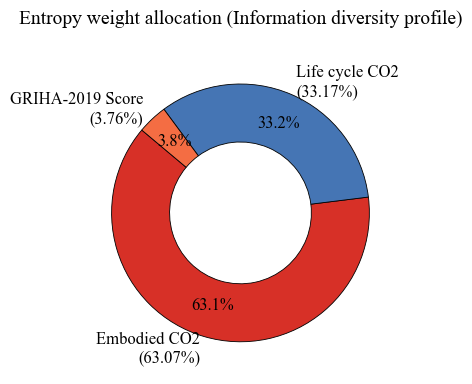

In [14]:
import matplotlib.pyplot as plt

# --- PRE-REQUISITE PARAMETERS (Ensure these variables match your dataset) ---
# weights = [0.2244, 0.1635, 0.1935, 0.1078, 0.1935, 0.1078, 0.0094] # Example array matching your colors/labels
# ----------------------------------------------------------------------------

# Initialize clean canvas layout metrics for standalone presentation
plt.rc('font', size=12, family='Times New Roman')
fig, ax = plt.subplots(figsize=(5, 4))

colors_3 = ['#d73027', '#4575b4', '#f46d43']
clean_labels = [
    'Embodied CO2', 'Life cycle CO2',  'GRIHA-2019 Score'
]
weight_labels = [f"{name}\n({w*100:.2f}%)" for name, w in zip(clean_labels, weights)]

# Plotting the Donut Chart
ax.pie(weights, labels=weight_labels, autopct='%1.1f%%', startangle=140, colors=colors_3,
       wedgeprops=dict(edgecolor='black', linewidth=0.6, width=0.45), pctdistance=0.75)

ax.set_title('Entropy weight allocation (Information diversity profile)', fontsize=14, pad=20)

plt.tight_layout()
plt.savefig('graph_A_entropy_weights.pdf', bbox_inches='tight', dpi=600)
plt.show()

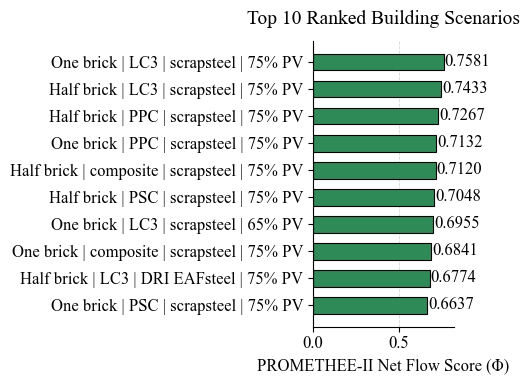

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# Publication-quality settings
# ==========================================================
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})

# ==========================================================
# Sort and select Top 10
# ==========================================================
top_10 = (
    df.sort_values("Phi", ascending=False)
      .head(10)
      .iloc[::-1]
)

# ==========================================================
# Figure
# ==========================================================
fig, ax = plt.subplots(figsize=(5, 4))

bars = ax.barh(
    top_10["Scenario Combination"],
    top_10["Phi"],
    color="#2E8B57",
    edgecolor="black",
    linewidth=0.8,
    height=0.62
)

# ==========================================================
# Axis formatting
# ==========================================================
xmin = 0
xmax = top_10["Phi"].max() * 1.08

ax.set_xlim(xmin, xmax)

ax.set_xlabel("PROMETHEE-II Net Flow Score (Φ)")
ax.set_ylabel("")
ax.set_title("Top 10 Ranked Building Scenarios", pad=12)

# Grid
ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.6,
    alpha=0.5
)

ax.set_axisbelow(True)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ==========================================================
# Annotate values
# ==========================================================
offset = (xmax - xmin) * 0.008

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + offset,
        bar.get_y() + bar.get_height()/2,
        f"{width:.4f}",
        va="center",
        ha="left",
        fontsize=12
    )

# ==========================================================
# Improve layout
# ==========================================================
plt.tight_layout()

# Save
plt.savefig(
    "graph_B_top_10_leaderboard.pdf",
    dpi=600,
    bbox_inches="tight"
)


plt.show()

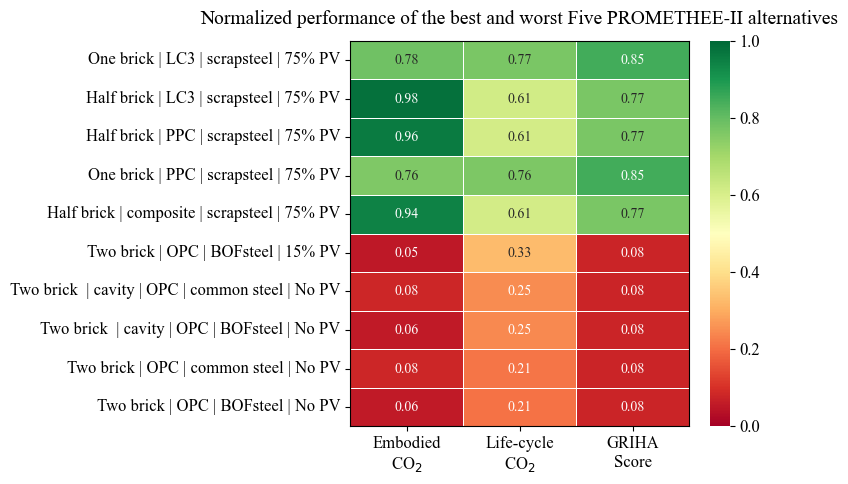

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ==========================================================
# Publication-quality settings
# ==========================================================
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

# ==========================================================
# Sort by PROMETHEE-II Net Flow
# ==========================================================
df_sorted = (
    df.sort_values("Phi", ascending=False)
      .reset_index(drop=True)
)

# ==========================================================
# Normalize criteria (0 = Worst, 1 = Best)
# ==========================================================
df_norm = pd.DataFrame(index=df_sorted.index)

for col in criteria_columns:

    values = df_sorted[col].astype(float)

    minimum = values.min()
    maximum = values.max()

    if "GRIHA" in col:
        # Benefit criterion
        df_norm[col] = (values - minimum) / (maximum - minimum)
    else:
        # Cost criteria
        df_norm[col] = (maximum - values) / (maximum - minimum)

# ==========================================================
# Best 5 and Worst 5
# ==========================================================
top_bottom = pd.concat([
    df_sorted.head(5),
    df_sorted.tail(5)
])

heatmap_df = df_norm.loc[top_bottom.index].copy()

# ==========================================================
# Column labels
# ==========================================================
heatmap_df.columns = [
    "Embodied\nCO$_2$",
    "Life-cycle\nCO$_2$",
    "GRIHA\nScore"
]

# ==========================================================
# ==========================================================
# Use full scenario names
# ==========================================================
heatmap_df.index = top_bottom["Scenario Combination"].values

# ==========================================================
# Plot
# ==========================================================
fig, ax = plt.subplots(figsize=(8,5))

sns.heatmap(
    heatmap_df,
    cmap="RdYlGn",
    vmin=0,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.6,
    linecolor="white",
    annot_kws={
        "fontsize":10
    },
    ax=ax
)

# ==========================================================
# Titles
# ==========================================================
ax.set_title(
    "Normalized performance of the best and worst Five PROMETHEE-II alternatives",
    pad=12
)

ax.set_xlabel("")
ax.set_ylabel("")

# ==========================================================
# Tick formatting
# ==========================================================
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)

# ==========================================================
# Black border around heatmap
# ==========================================================
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)
    spine.set_color("black")

# ==========================================================

plt.tight_layout()

plt.savefig(
    "graph_D_clean_names_heatmap.pdf",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [17]:
# ==========================================================
# Worst 5 scenarios with actual values
# ==========================================================
worst_5 = (
    df_sorted.tail(5)[
        ["Scenario Combination",
         "Embodied impact(kgCO2)",
         "Life cycle impact(kgCO2)",
         "GRIHA-2019 score",
         "Phi"]
    ]
    .copy()
)

print("\nWorst 5 PROMETHEE-II scenarios:")
print(worst_5.to_string(index=False))


Worst 5 PROMETHEE-II scenarios:
                            Scenario Combination  Embodied impact(kgCO2)  Life cycle impact(kgCO2)  GRIHA-2019 score       Phi
             Two brick | OPC | BOFsteel | 15% PV            3.242508e+06              2.839197e+07                57 -0.833079
Two brick  | cavity | OPC | common steel | No PV            3.196014e+06              2.965416e+07                57 -0.849103
    Two brick  | cavity | OPC | BOFsteel | No PV            3.233968e+06              2.969212e+07                57 -0.874163
          Two brick | OPC | common steel | No PV            3.196014e+06              3.024086e+07                57 -0.875388
              Two brick | OPC | BOFsteel | No PV            3.233968e+06              3.027882e+07                57 -0.902523
